# __TTT4275 Estimation, Detection and Classification__

## Classification Problem Set 1

__From task sheet__: The main topic for this problem set is an investigation of the importance of dataset sizes. The task should preferably be implemented in MATLAB or Python. We shall work with computer-generated data, i.e., we know the true performance. To visualize, we use
two classes of Gaussian-distributed scalar data $x$. The mean of the two classes are $m_1 = −1$ and $m_2 = 1$ respectively. The two class variances are identical denoted as $\sigma^2$. Further, assume equal probability (priors) for the two classes, namely $P_1 = P_2 = 0.5$.

Generating three datasets, each containing 1000 samples from each class. The three datasets of size 2000 has following values for variance:

$\sigma_1^2 = 0.25$

$\sigma_2^2= 0.49$

$\sigma_3^2= 1.00$

These dataset are used multiple times during the exercise. The first 500 samples in each class will be used for training and the last 500 for testing

In [160]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [161]:
N = 1000
mu_1, mu_2 = -1, 1
variances = [0.25, 0.49, 1.00]
datasets = []
for var in variances:
    std_dev = np.sqrt(var)
    class1 = np.random.normal(mu_1, std_dev, N)
    class2 = np.random.normal(mu_2, std_dev, N)
    datasets.append((class1, class2))

### __Problem 1__

__(a)__ Plot histograms for the three __test datasets__ using different colors for the two classes. What can you say about the difficulty of classifying them (in terms of the error rate)?

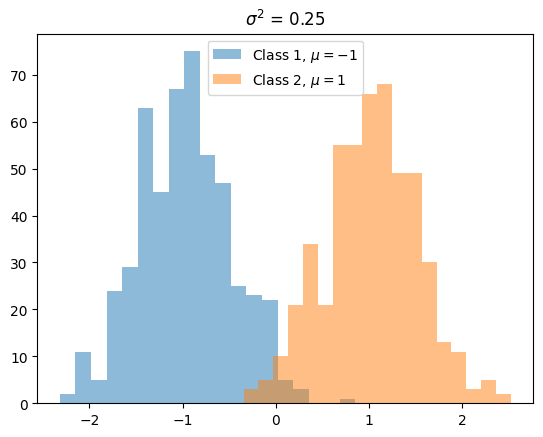

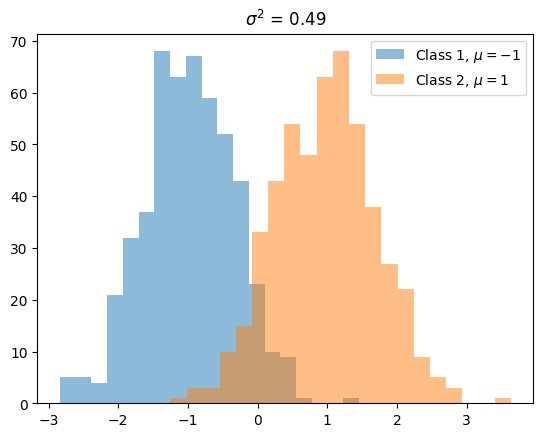

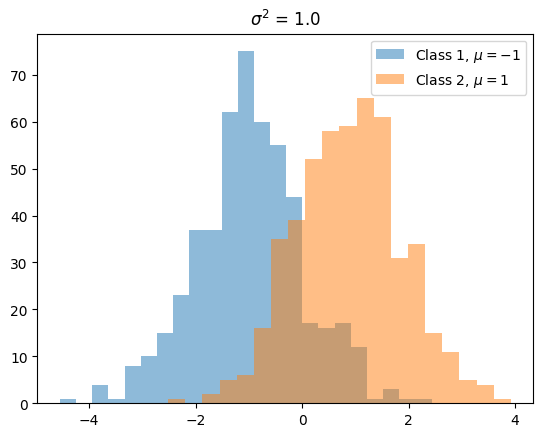

In [162]:
for i, (class1, class2) in enumerate(datasets):
    plt.figure()
    plt.hist(class1[500:], alpha=0.5, bins='auto', label=r'Class 1, $\mu = -1$')
    plt.hist(class2[500:], alpha=0.5, bins='auto', label=r'Class 2, $\mu = 1$')
    plt.title(f'$\sigma^2$ = {variances[i]}')
    plt.legend()

plt.show()

We see that figure one has less overlap while figure 3 has most overlap. This is as expected because the higher the varaiance, the larger the ranges of values, the greater the error rate. 

More overlap = more errors = harder classification.

__(b)__ Assume the true class densities are known. From statistical theory, calculate the true error rate for the three variance cases.

From Detection theory, we know that probability of error is 

$$P_e = \pi_0\text{Prob}\{\delta(x)=1|H_0\} + \pi_1\text{Prob}\{\delta(x)=0|H_1\}$$

In our case, we let $P_1 = P_2 = \pi_0 = \pi_1 = 0.5$. For class 1, error happens when a sample from $C_1$ is classified as $C_2$, for example when x > 0 (because we are told given the means, same variance and equal priors, int this case, the optimal decision boundary is in the middle), so 

$$P(x > 0 | C_1) = \int_0^{\infty}\frac{1}{\sqrt{2\pi \sigma^2}}\text{exp}(-\frac{1}{2}\frac{(x+1)^2}{\sigma^2})dx$$

For class 2, the error happens when x<0, so

$$P(x < 0 | C_2) = \int_{-\infty}^{0}\frac{1}{\sqrt{2\pi \sigma^2}}\text{exp}(-\frac{1}{2}\frac{(x-1)^2}{\sigma^2})dx$$

Because of symmetry (if you mirror one of the distributions around x=0 then you get the other distribution) we have 

$$P_e=P(x>0|C_1)$$

thus we focus on

$$P(x > 0 | C_1) = \int_0^{\infty}\frac{1}{\sqrt{2\pi \sigma^2}}\text{exp}(-\frac{1}{2}\frac{(x+1)^2}{\sigma^2})dx$$

using substitution where $y=\frac{x-\mu}{\sigma}=\frac{x+1}{\sigma}$, which gives $\frac{dy}{dx} = \frac{1}{\sigma}$, we get

$$P(x > 0 | C_1) = \int_{\frac{1}{\sigma}}^{\infty}\frac{1}{\sqrt{2\pi}}\text{exp}(-\frac{y}{2})dx = 1 - \Phi(\frac{1}{\sigma}) = \frac{1}{\sqrt{2\pi}}\int_z^{\infty}\text{exp}(-\frac{y^2}{2})$$

we know

$$erfc(z) = \frac{2}{sqrt{\pi}}\int_z^{\infty}\text{exp}(-t^2)$$

where in our case it becomes 

$$P_e = \frac{1}{2}\text{erfc}(\frac{1}{\sigma\sqrt{2}})$$

Calculating the true error rate for the three variance instances:

In [163]:
for var in variances:
    sigma = np.sqrt(var)
    true_error_rate = 1 - sp.stats.norm.cdf(1/sigma)
    print(f"True error rate for $\sigma^2$={var} is {round(true_error_rate, 4)}")

True error rate for $\sigma^2$=0.25 is 0.0228
True error rate for $\sigma^2$=0.49 is 0.0766
True error rate for $\sigma^2$=1.0 is 0.1587


__(c)__  Now, focus on one of the datasets and use the true densities for the class models. Pick $N_T$ samples for each class from the test dataset, and find the corresponding estimated error rate. Do this for:

* Three sizes: $N_T$ = 5, 20, 100 (per class).
* Repeat the experiment 4 more times for each $N_T$. Ensure that no samples are ”reused” during these 5 tests!
* Find the confusion matrices and compare them.
* Compute the averaged confusion matrices and the corresponding error rates over the five experiments for each given $N_T$ 

In [164]:
NT_samples = [5, 20, 100]
class1_test = datasets[0][0][500:]
class2_test = datasets[0][1][500:]

def classify(x):
    return np.where(x < 0, 1, 2) # if-else (rule, if true, if false) makes array

for sample in NT_samples:
    conf_matrices = []
    for j in range(5):
        c1 = class1_test[j*sample : (j+1)*sample]
        c2 = class2_test[j*sample : (j+1)*sample]
        
        pred_c1 = classify(c1)
        pred_c2 = classify(c2)

        conf = np.array([
            [np.sum(pred_c1 == 1), np.sum(pred_c1 == 2)], 
            [np.sum(pred_c2 == 1), np.sum(pred_c2 == 2)]
        ])

        conf_matrices.append(conf)
        print(f"N_T={sample}, experiemnt {j+1}:\n{conf}")

        errors_c1 = np.sum(pred_c1 != 1)
        errors_c2 = np.sum(pred_c2 != 2)

        total_errors = errors_c1 + errors_c2
        total_samples = 2*sample
        error_rate = total_errors / total_samples

        print(f"Errors: {total_errors} / {total_samples} = {error_rate}\n")
    
    avg_conf = np.mean(conf_matrices, axis=0)
    error_rate = (avg_conf[0,1] + avg_conf[1,0]) / (2 * sample)
    print(f"N_T={sample} averaged confusion matrix:\n{avg_conf}")
    print(f"N_T={sample} averaged error rate: {error_rate:.4f}\n")
    print("-"*40)

N_T=5, experiemnt 1:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5, experiemnt 2:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5, experiemnt 3:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5, experiemnt 4:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5, experiemnt 5:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5 averaged confusion matrix:
[[5. 0.]
 [0. 5.]]
N_T=5 averaged error rate: 0.0000

----------------------------------------
N_T=20, experiemnt 1:
[[20  0]
 [ 0 20]]
Errors: 0 / 40 = 0.0

N_T=20, experiemnt 2:
[[20  0]
 [ 0 20]]
Errors: 0 / 40 = 0.0

N_T=20, experiemnt 3:
[[20  0]
 [ 0 20]]
Errors: 0 / 40 = 0.0

N_T=20, experiemnt 4:
[[20  0]
 [ 0 20]]
Errors: 0 / 40 = 0.0

N_T=20, experiemnt 5:
[[19  1]
 [ 0 20]]
Errors: 1 / 40 = 0.025

N_T=20 averaged confusion matrix:
[[19.8  0.2]
 [ 0.  20. ]]
N_T=20 averaged error rate: 0.0050

----------------------------------------
N_T=100, experiemnt 1:
[[ 99   1]
 [  0 100]]
Errors: 1 / 200 = 0.005

N_T=100, experiemnt 2:
[[97  3]
 [ 3 97]]
Errors: 6 / 20

Making code for the plot of confusion matrices

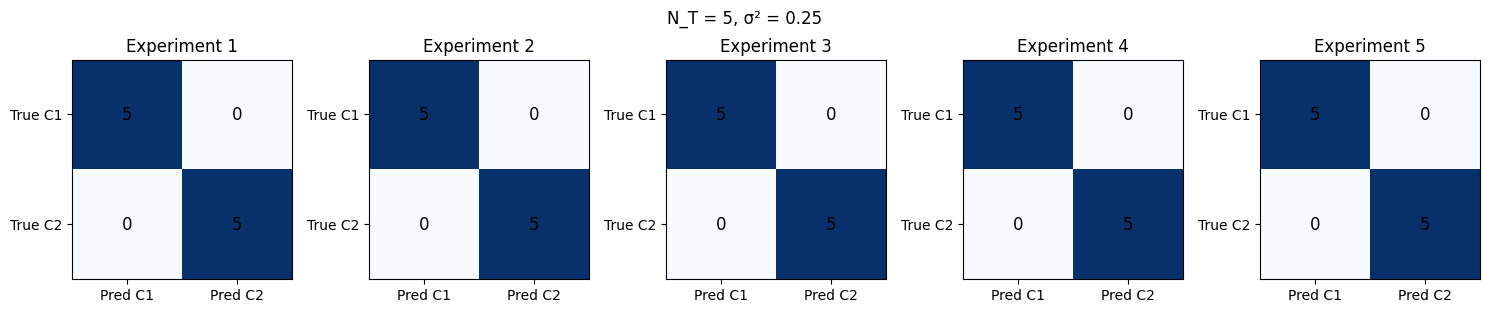

N_T=5 averaged error rate: 0.0000


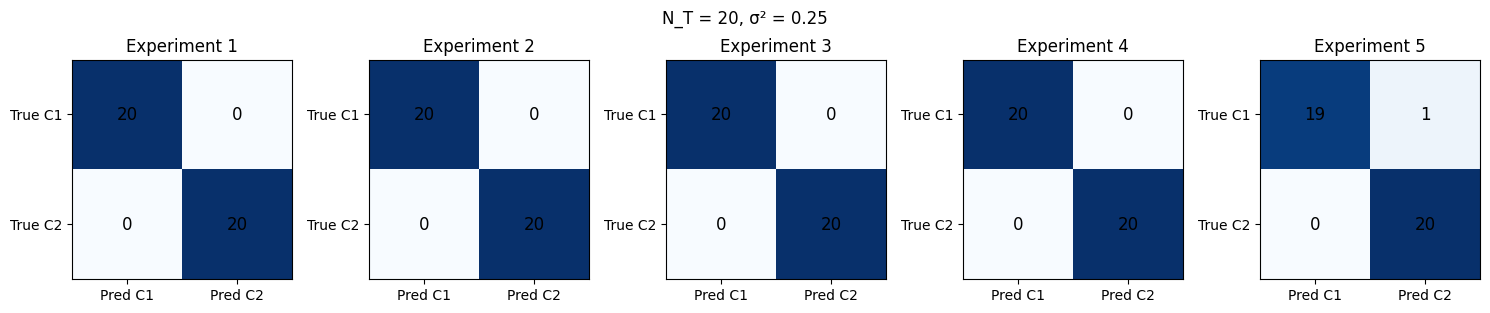

N_T=20 averaged error rate: 0.0050


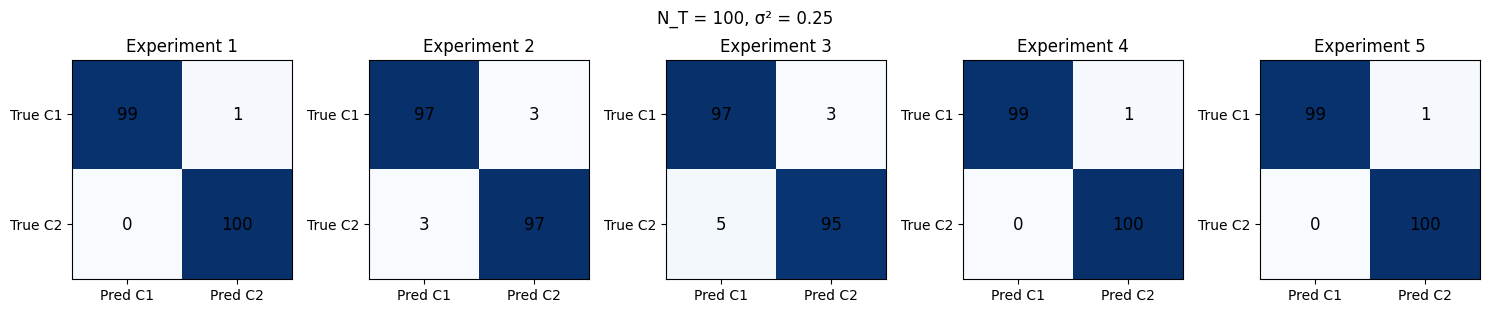

N_T=100 averaged error rate: 0.0170


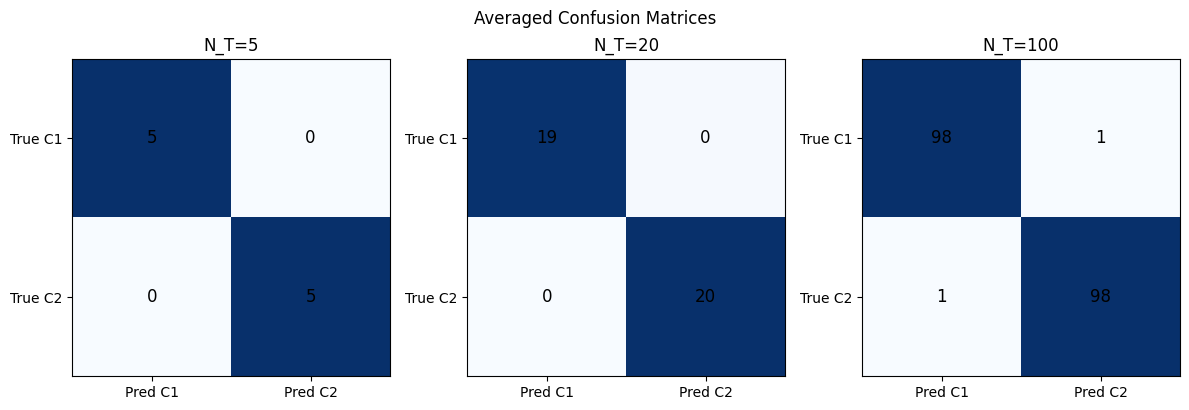

In [165]:
avg_conf_matrices = []  # store one averaged matrix per N_T

for sample in NT_samples:
    conf_matrices = []
    
    for j in range(5):
        c1 = class1_test[j*sample : (j+1)*sample]
        c2 = class2_test[j*sample : (j+1)*sample]
        pred_c1 = classify(c1)
        pred_c2 = classify(c2)
        
        conf = np.array([
            [np.sum(pred_c1 == 1), np.sum(pred_c1 == 2)],
            [np.sum(pred_c2 == 1), np.sum(pred_c2 == 2)]
        ])
        conf_matrices.append(conf)
    
    # Plot 5 individual matrices
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for j, conf in enumerate(conf_matrices):
        plot_confusion_matrix(conf, title=f'Experiment {j+1}', ax=axes[j])
    plt.suptitle(f'N_T = {sample}, σ² = {variances[0]}')
    plt.tight_layout()
    plt.show()
    
    avg_conf = np.mean(conf_matrices, axis=0)
    avg_conf_matrices.append(avg_conf)
    error_rate = (avg_conf[0,1] + avg_conf[1,0]) / (2 * sample)
    print(f"N_T={sample} averaged error rate: {error_rate:.4f}")

# Plot 3 averaged matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (sample, avg_conf) in enumerate(zip(NT_samples, avg_conf_matrices)):
    plot_confusion_matrix(avg_conf, title=f'N_T={sample}', ax=axes[i])
plt.suptitle('Averaged Confusion Matrices')
plt.tight_layout()
plt.show()


__(d)__ Will the average error rate from __(c)__ differ from the error rate obtained when using all five test sets in a single test?

__A__: No. It is the classifier that chooses the error rate. Using the same classifier for the other five test sets and averaging will give approximately the same answer. 

__(e)__ Repeat all the above steps for the remaining two datasets.

First for the second data set

In [166]:
NT_samples = [5, 20, 100]
class1_test = datasets[1][0][500:]
class2_test = datasets[1][1][500:]

def classify(x):
    return np.where(x < 0, 1, 2) # if-else (rule, if true, if false) makes array

for sample in NT_samples:
    conf_matrices = []
    for j in range(5):
        c1 = class1_test[j*sample : (j+1)*sample]
        c2 = class2_test[j*sample : (j+1)*sample]
        
        pred_c1 = classify(c1)
        pred_c2 = classify(c2)

        conf = np.array([
            [np.sum(pred_c1 == 1), np.sum(pred_c1 == 2)], 
            [np.sum(pred_c2 == 1), np.sum(pred_c2 == 2)]
        ])

        conf_matrices.append(conf)
        print(f"N_T={sample}, experiemnt {j+1}:\n{conf}")

        errors_c1 = np.sum(pred_c1 != 1)
        errors_c2 = np.sum(pred_c2 != 2)

        total_errors = errors_c1 + errors_c2
        total_samples = 2*sample
        error_rate = total_errors / total_samples

        print(f"Errors: {total_errors} / {total_samples} = {error_rate}\n")
    
    avg_conf = np.mean(conf_matrices, axis=0)
    error_rate = (avg_conf[0,1] + avg_conf[1,0]) / (2 * sample)
    print(f"N_T={sample} averaged confusion matrix:\n{avg_conf}")
    print(f"N_T={sample} averaged error rate: {error_rate:.4f}\n")
    print("-"*40)

N_T=5, experiemnt 1:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5, experiemnt 2:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5, experiemnt 3:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5, experiemnt 4:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5, experiemnt 5:
[[4 1]
 [1 4]]
Errors: 2 / 10 = 0.2

N_T=5 averaged confusion matrix:
[[4.8 0.2]
 [0.2 4.8]]
N_T=5 averaged error rate: 0.0400

----------------------------------------
N_T=20, experiemnt 1:
[[20  0]
 [ 0 20]]
Errors: 0 / 40 = 0.0

N_T=20, experiemnt 2:
[[17  3]
 [ 1 19]]
Errors: 4 / 40 = 0.1

N_T=20, experiemnt 3:
[[19  1]
 [ 1 19]]
Errors: 2 / 40 = 0.05

N_T=20, experiemnt 4:
[[20  0]
 [ 0 20]]
Errors: 0 / 40 = 0.0

N_T=20, experiemnt 5:
[[19  1]
 [ 3 17]]
Errors: 4 / 40 = 0.1

N_T=20 averaged confusion matrix:
[[19.  1.]
 [ 1. 19.]]
N_T=20 averaged error rate: 0.0500

----------------------------------------
N_T=100, experiemnt 1:
[[95  5]
 [ 5 95]]
Errors: 10 / 200 = 0.05

N_T=100, experiemnt 2:
[[94  6]
 [ 7 93]]
Errors: 13 / 200 = 

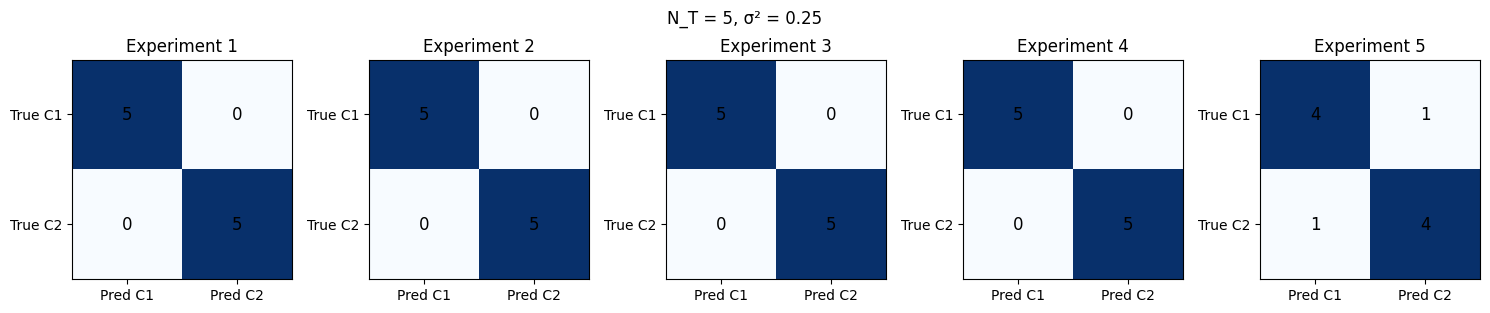

N_T=5 averaged error rate: 0.0400


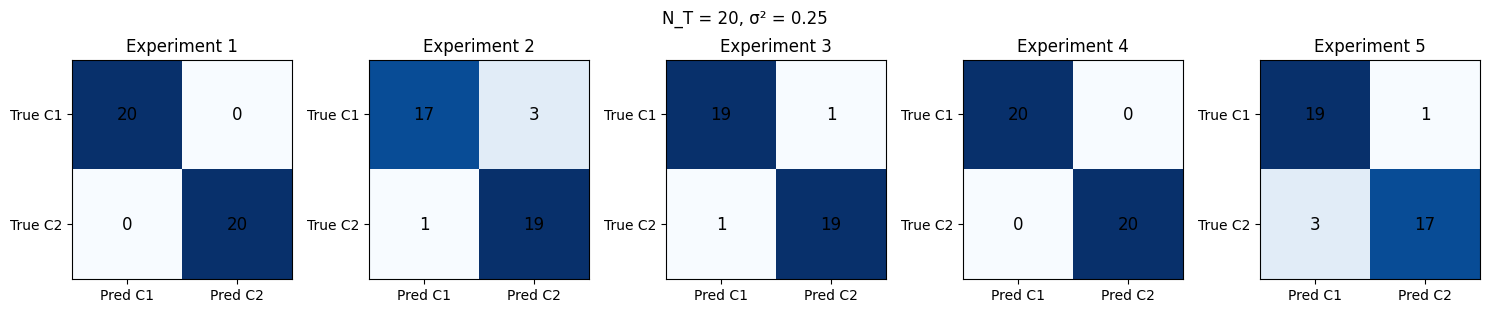

N_T=20 averaged error rate: 0.0500


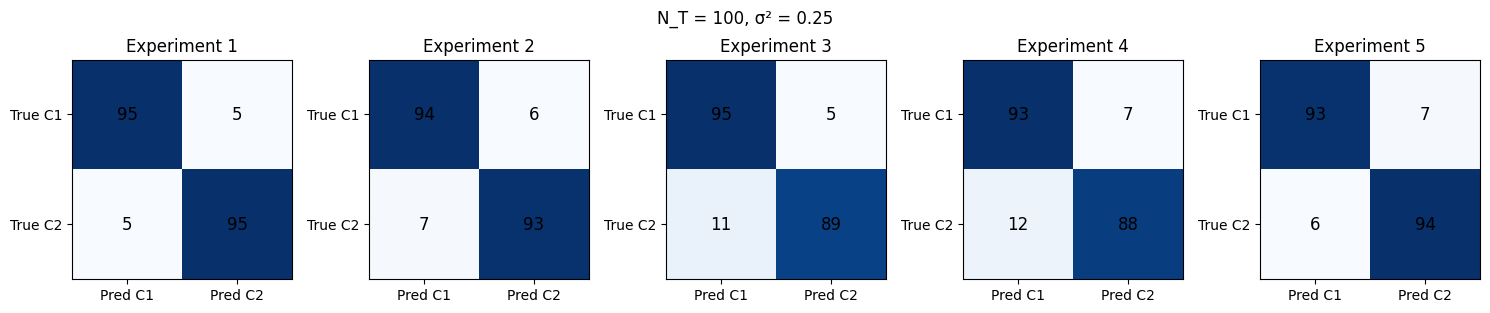

N_T=100 averaged error rate: 0.0710


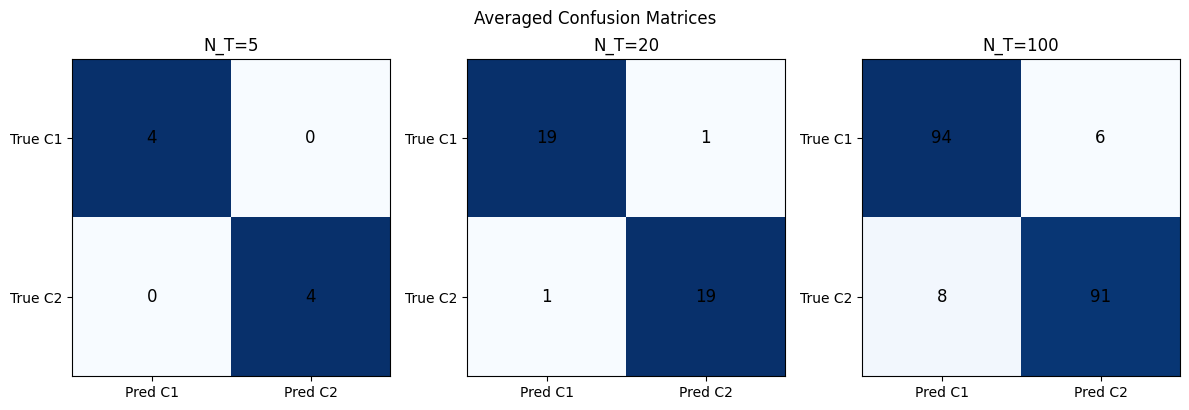

In [167]:
avg_conf_matrices = []  # store one averaged matrix per N_T

for sample in NT_samples:
    conf_matrices = []
    
    for j in range(5):
        c1 = class1_test[j*sample : (j+1)*sample]
        c2 = class2_test[j*sample : (j+1)*sample]
        pred_c1 = classify(c1)
        pred_c2 = classify(c2)
        
        conf = np.array([
            [np.sum(pred_c1 == 1), np.sum(pred_c1 == 2)],
            [np.sum(pred_c2 == 1), np.sum(pred_c2 == 2)]
        ])
        conf_matrices.append(conf)
    
    # Plot 5 individual matrices
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for j, conf in enumerate(conf_matrices):
        plot_confusion_matrix(conf, title=f'Experiment {j+1}', ax=axes[j])
    plt.suptitle(f'N_T = {sample}, σ² = {variances[0]}')
    plt.tight_layout()
    plt.show()
    
    avg_conf = np.mean(conf_matrices, axis=0)
    avg_conf_matrices.append(avg_conf)
    error_rate = (avg_conf[0,1] + avg_conf[1,0]) / (2 * sample)
    print(f"N_T={sample} averaged error rate: {error_rate:.4f}")

# Plot 3 averaged matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (sample, avg_conf) in enumerate(zip(NT_samples, avg_conf_matrices)):
    plot_confusion_matrix(avg_conf, title=f'N_T={sample}', ax=axes[i])
plt.suptitle('Averaged Confusion Matrices')
plt.tight_layout()
plt.show()


Then for the final set

In [168]:
NT_samples = [5, 20, 100]
class1_test = datasets[2][0][500:]
class2_test = datasets[2][1][500:]

def classify(x):
    return np.where(x < 0, 1, 2) # if-else (rule, if true, if false) makes array

for sample in NT_samples:
    conf_matrices = []
    for j in range(5):
        c1 = class1_test[j*sample : (j+1)*sample]
        c2 = class2_test[j*sample : (j+1)*sample]
        
        pred_c1 = classify(c1)
        pred_c2 = classify(c2)

        conf = np.array([
            [np.sum(pred_c1 == 1), np.sum(pred_c1 == 2)], 
            [np.sum(pred_c2 == 1), np.sum(pred_c2 == 2)]
        ])

        conf_matrices.append(conf)
        print(f"N_T={sample}, experiemnt {j+1}:\n{conf}")

        errors_c1 = np.sum(pred_c1 != 1)
        errors_c2 = np.sum(pred_c2 != 2)

        total_errors = errors_c1 + errors_c2
        total_samples = 2*sample
        error_rate = total_errors / total_samples

        print(f"Errors: {total_errors} / {total_samples} = {error_rate}\n")
    
    avg_conf = np.mean(conf_matrices, axis=0)
    error_rate = (avg_conf[0,1] + avg_conf[1,0]) / (2 * sample)
    print(f"N_T={sample} averaged confusion matrix:\n{avg_conf}")
    print(f"N_T={sample} averaged error rate: {error_rate:.4f}\n")
    print("-"*40)

N_T=5, experiemnt 1:
[[5 0]
 [2 3]]
Errors: 2 / 10 = 0.2

N_T=5, experiemnt 2:
[[5 0]
 [2 3]]
Errors: 2 / 10 = 0.2

N_T=5, experiemnt 3:
[[5 0]
 [1 4]]
Errors: 1 / 10 = 0.1

N_T=5, experiemnt 4:
[[4 1]
 [1 4]]
Errors: 2 / 10 = 0.2

N_T=5, experiemnt 5:
[[5 0]
 [0 5]]
Errors: 0 / 10 = 0.0

N_T=5 averaged confusion matrix:
[[4.8 0.2]
 [1.2 3.8]]
N_T=5 averaged error rate: 0.1400

----------------------------------------
N_T=20, experiemnt 1:
[[19  1]
 [ 6 14]]
Errors: 7 / 40 = 0.175

N_T=20, experiemnt 2:
[[18  2]
 [ 3 17]]
Errors: 5 / 40 = 0.125

N_T=20, experiemnt 3:
[[17  3]
 [ 3 17]]
Errors: 6 / 40 = 0.15

N_T=20, experiemnt 4:
[[18  2]
 [ 3 17]]
Errors: 5 / 40 = 0.125

N_T=20, experiemnt 5:
[[18  2]
 [ 0 20]]
Errors: 2 / 40 = 0.05

N_T=20 averaged confusion matrix:
[[18.  2.]
 [ 3. 17.]]
N_T=20 averaged error rate: 0.1250

----------------------------------------
N_T=100, experiemnt 1:
[[90 10]
 [15 85]]
Errors: 25 / 200 = 0.125

N_T=100, experiemnt 2:
[[83 17]
 [23 77]]
Errors: 40 

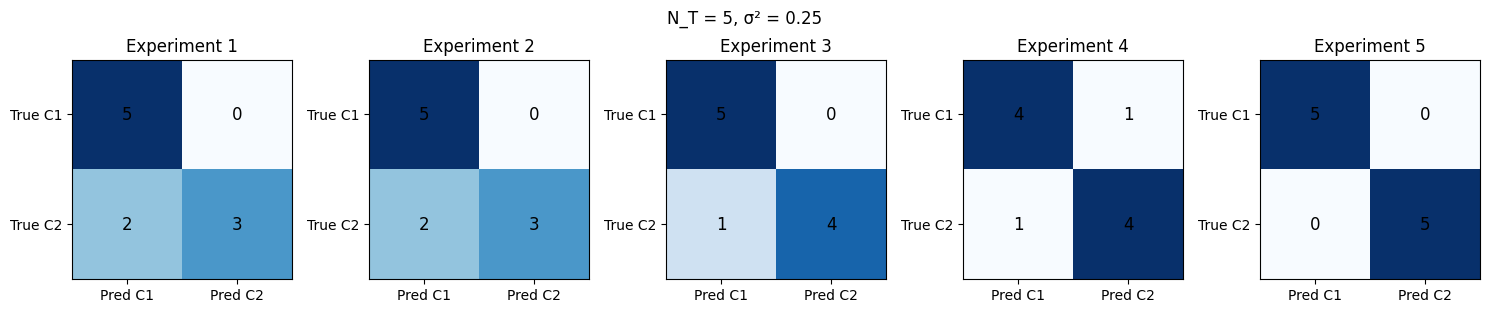

N_T=5 averaged error rate: 0.1400


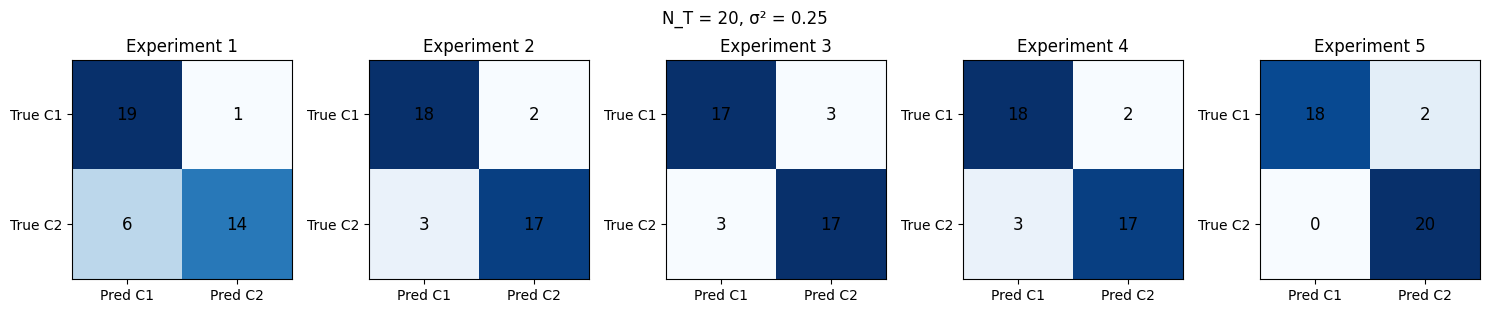

N_T=20 averaged error rate: 0.1250


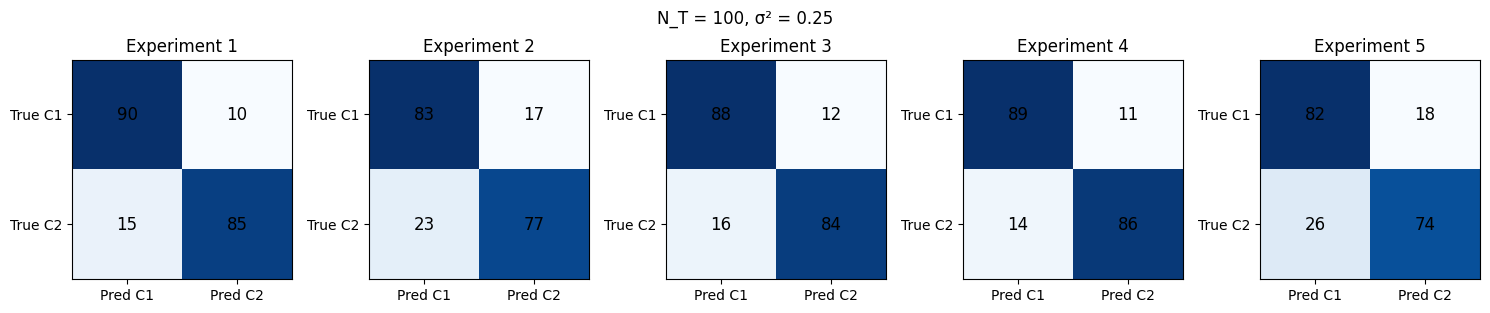

N_T=100 averaged error rate: 0.1620


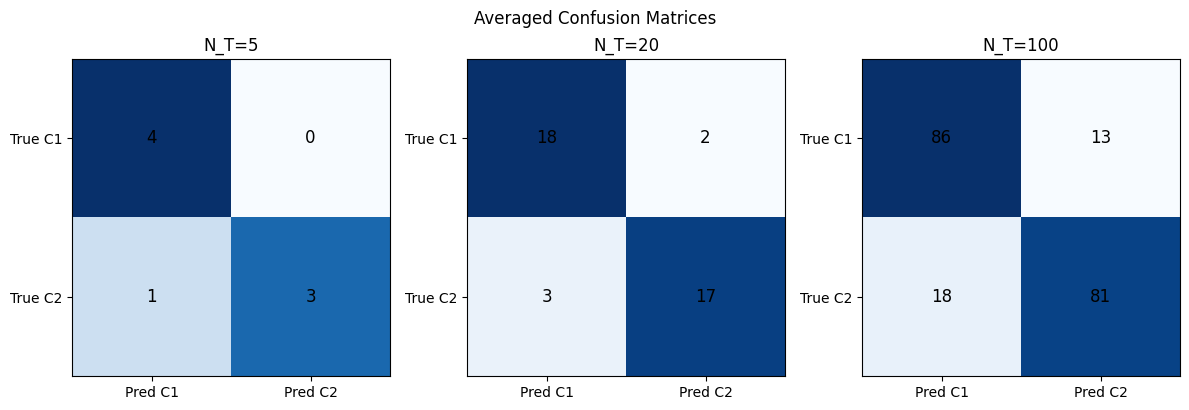

In [169]:
avg_conf_matrices = []  # store one averaged matrix per N_T

for sample in NT_samples:
    conf_matrices = []
    
    for j in range(5):
        c1 = class1_test[j*sample : (j+1)*sample]
        c2 = class2_test[j*sample : (j+1)*sample]
        pred_c1 = classify(c1)
        pred_c2 = classify(c2)
        
        conf = np.array([
            [np.sum(pred_c1 == 1), np.sum(pred_c1 == 2)],
            [np.sum(pred_c2 == 1), np.sum(pred_c2 == 2)]
        ])
        conf_matrices.append(conf)
    
    # Plot 5 individual matrices
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for j, conf in enumerate(conf_matrices):
        plot_confusion_matrix(conf, title=f'Experiment {j+1}', ax=axes[j])
    plt.suptitle(f'N_T = {sample}, σ² = {variances[0]}')
    plt.tight_layout()
    plt.show()
    
    avg_conf = np.mean(conf_matrices, axis=0)
    avg_conf_matrices.append(avg_conf)
    error_rate = (avg_conf[0,1] + avg_conf[1,0]) / (2 * sample)
    print(f"N_T={sample} averaged error rate: {error_rate:.4f}")

# Plot 3 averaged matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (sample, avg_conf) in enumerate(zip(NT_samples, avg_conf_matrices)):
    plot_confusion_matrix(avg_conf, title=f'N_T={sample}', ax=axes[i])
plt.suptitle('Averaged Confusion Matrices')
plt.tight_layout()
plt.show()


We see that the higher the variance, the higher the error rates. We also see that the variation decreases when increasing the sample length.



### __Problem 2__

Instead of using the true class models, we will now train the class models. For each of the three datasets, perform the following:

__(a)__ Use the first $N_D$ training samples of each class to train/estimate the parameters of a Gaussian classifier. Use all 500 test samples for each class during a subsequent test. Do this for:
*  Three training set sizes: $N_D$ = 5, 20, 100 from each class.
* Repeat the experiment 4 times for each $N_D$ by using different training samples (no reuse!).
* Find the confusion matrices and compare them.
* Compute the averaged error rate over the five tests for each given $N_D$.

In [ ]:
ND_samples = [5, 20, 100]
class1_test = datasets[0][0][500:]
class2_test = datasets[0][0][500:]

for sample in ND_samples:
    c1_train_set = datasets[0][0][:500]
    c2_train_set = datasets[0][1][:500]
    conf_matrices = []

    for j in range(5):
        c1_train = c1_train_set[j*sample : (j+1)*sample]
        c2_train = c2_train_set[j*sample : (j+1)*sample]


        mu1_est = np.mean(c1_train)
        mu2_est = np.mean(c2_train)
        boundary = (mu1_est + mu2_est) / 2
        
        def classify_trained(x):
            return np.where(x < boundary, 1, 2)
        
        pred_c1 = classify_trained(class1_test)
        pred_c2 = classify_trained(class2_test)


        conf = np.array([
            [np.sum(pred_c1 == 1), np.sum(pred_c1 == 2)],
            [np.sum(pred_c2 == 1), np.sum(pred_c2 == 2)]
        ])
        conf_matrices.append(conf)
        print(f"N_D={sample}, experiment {j+1}:\n{conf}\n")

    avg_conf = np.mean(conf_matrices, axis=0)
    error_rate = (avg_conf[0,1] + avg_conf[1,0]) / (2 * 500)
    print(f"N_D={sample} averaged confusion matrix:\n{avg_conf}")
    print(f"N_D={sample} averaged error rate: {error_rate:.4f}\n")
    print("-"*40)


N_D=5, experiment 1:
[[420  80]
 [ 79 421]]

N_D=5, experiment 2:
[[  0 500]
 [  0 500]]

N_D=5, experiment 3:
[[  0 500]
 [  0 500]]

N_D=5, experiment 4:
[[  0 500]
 [  0 500]]

N_D=5, experiment 5:
[[  0 500]
 [  0 500]]

N_D=5 averaged confusion matrix:
[[ 84.  416. ]
 [ 15.8 484.2]]
N_D=5 averaged error rate: 0.4318

----------------------------------------
N_D=20, experiment 1:
[[433  67]
 [ 97 403]]

N_D=20, experiment 2:
[[  0 500]
 [  0 500]]

N_D=20, experiment 3:
[[  0 500]
 [  0 500]]

N_D=20, experiment 4:
[[  0 500]
 [  0 500]]

N_D=20, experiment 5:
[[  0 500]
 [  0 500]]

N_D=20 averaged confusion matrix:
[[ 86.6 413.4]
 [ 19.4 480.6]]
N_D=20 averaged error rate: 0.4328

----------------------------------------
N_D=100, experiment 1:
[[434  66]
 [ 98 402]]

N_D=100, experiment 2:
[[  0 500]
 [  0 500]]

N_D=100, experiment 3:
[[  0 500]
 [  0 500]]

N_D=100, experiment 4:
[[  0 500]
 [  0 500]]

N_D=100, experiment 5:
[[  0 500]
 [  0 500]]

N_D=100 averaged confusion m

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


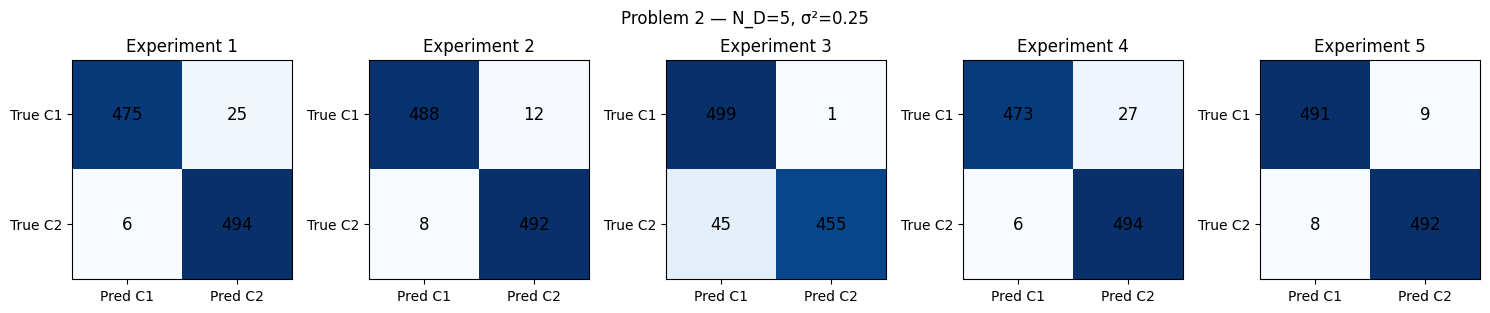

N_D=5 averaged error rate: 0.0294


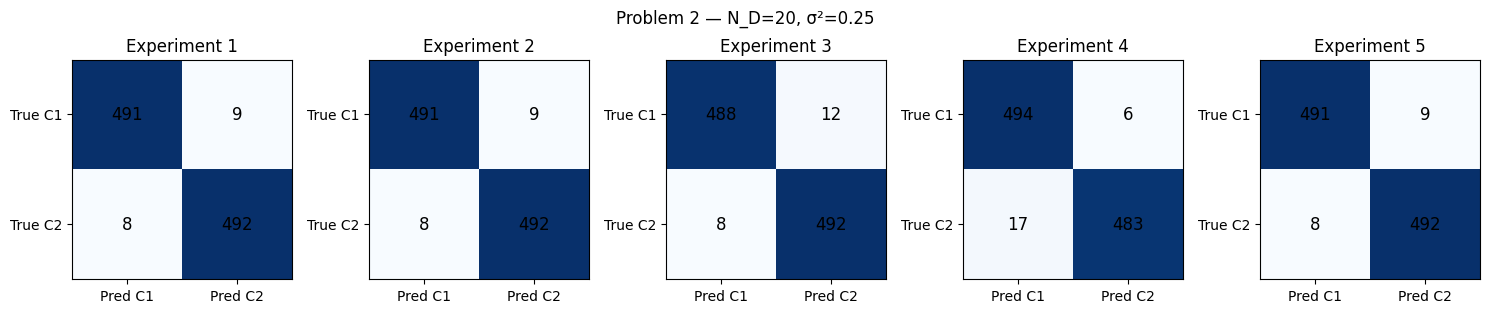

N_D=20 averaged error rate: 0.0188


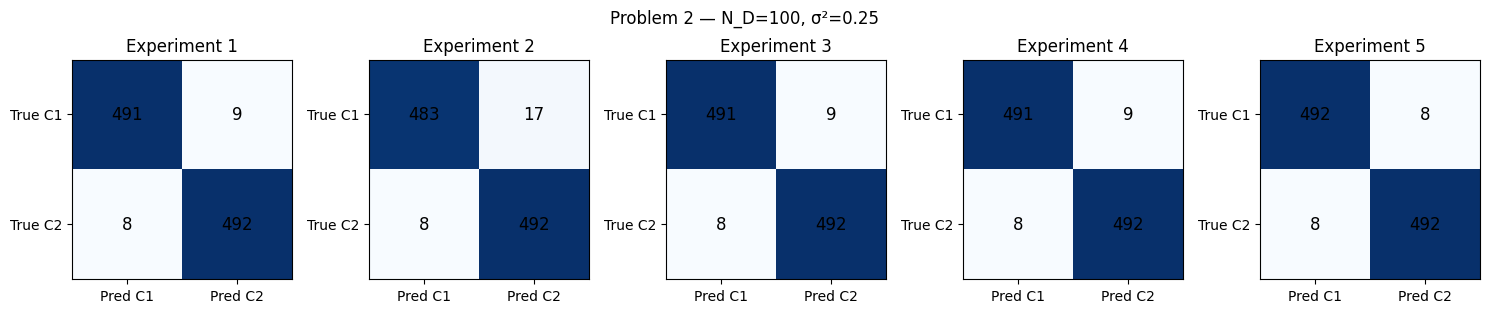

N_D=100 averaged error rate: 0.0184


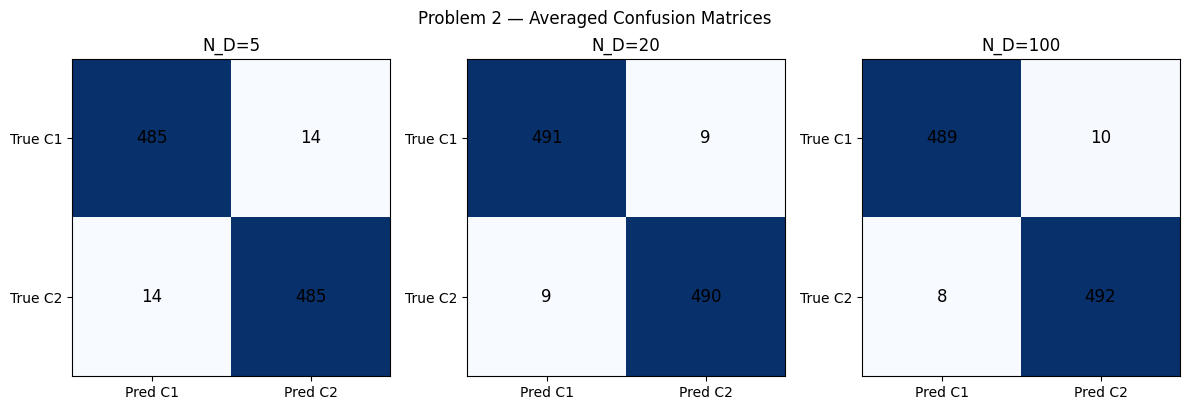

In [171]:
ND_samples = [5, 20, 100]

class1_test = datasets[0][0][500:]
class2_test = datasets[0][1][500:]

c1_train_set = datasets[0][0][:500]
c2_train_set = datasets[0][1][:500]

avg_conf_matrices_p2 = []

for sample in ND_samples:
    conf_matrices = []

    for j in range(5):
        c1_train = c1_train_set[j*sample : (j+1)*sample]
        c2_train = c2_train_set[j*sample : (j+1)*sample]

        mu1_est = np.mean(c1_train)
        mu2_est = np.mean(c2_train)
        boundary = (mu1_est + mu2_est) / 2

        pred_c1 = np.where(class1_test < boundary, 1, 2)
        pred_c2 = np.where(class2_test < boundary, 1, 2)

        conf = np.array([
            [np.sum(pred_c1 == 1), np.sum(pred_c1 == 2)],
            [np.sum(pred_c2 == 1), np.sum(pred_c2 == 2)]
        ])
        conf_matrices.append(conf)

    # Plot 5 individual matrices
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for j, conf in enumerate(conf_matrices):
        plot_confusion_matrix(conf, title=f'Experiment {j+1}', ax=axes[j])
    plt.suptitle(f'Problem 2 — N_D={sample}, σ²={variances[0]}')
    plt.tight_layout()
    plt.show()

    avg_conf = np.mean(conf_matrices, axis=0)
    avg_conf_matrices_p2.append(avg_conf)
    error_rate = (avg_conf[0,1] + avg_conf[1,0]) / (2 * 500)
    print(f"N_D={sample} averaged error rate: {error_rate:.4f}")

# Plot 3 averaged matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (sample, avg_conf) in enumerate(zip(ND_samples, avg_conf_matrices_p2)):
    plot_confusion_matrix(avg_conf, title=f'N_D={sample}', ax=axes[i])
plt.suptitle('Problem 2 — Averaged Confusion Matrices')
plt.tight_layout()
plt.show()


Notice that for the different plots, there is a large variation of errors when the amount of samples is small. The more samples there are, the less the errors vary. For small amount of samples the boundary is unstable and shifts, causing very different error rates. 

Dataset size matters. 

__(b)__ Will this error rate differ from the error rate obtained when using all five training sets in a single training?

Yes, now when we use all five training sets in a single training it will differ, compared to in Problem 1. The big variance because of the small dataset will have a big affect when combined with the large dataset with low variance. 

### __Problem 3__
Now, we will inspect the leave-one-out testing procedure for small datasets. Assume that the three datasets only have a total of 6 samples from each class (use the first 6 samples from the training set).

__(a)__ For each of the three datasets, do the following:
* Remove sample number $i$ = 1, . . . , 6 from both classes for testing and train with the remaining 5 samples per class (first remove $i$ = 1 then $i$ = 2 etc.). Classify the two test samples.
* Compute the average error rate over the 6 experiments. Compare the results with the performance of the comparable classifier in Problem 2 (i.e., $N_D$ = 5).

Dataset 1, σ² = 0.25


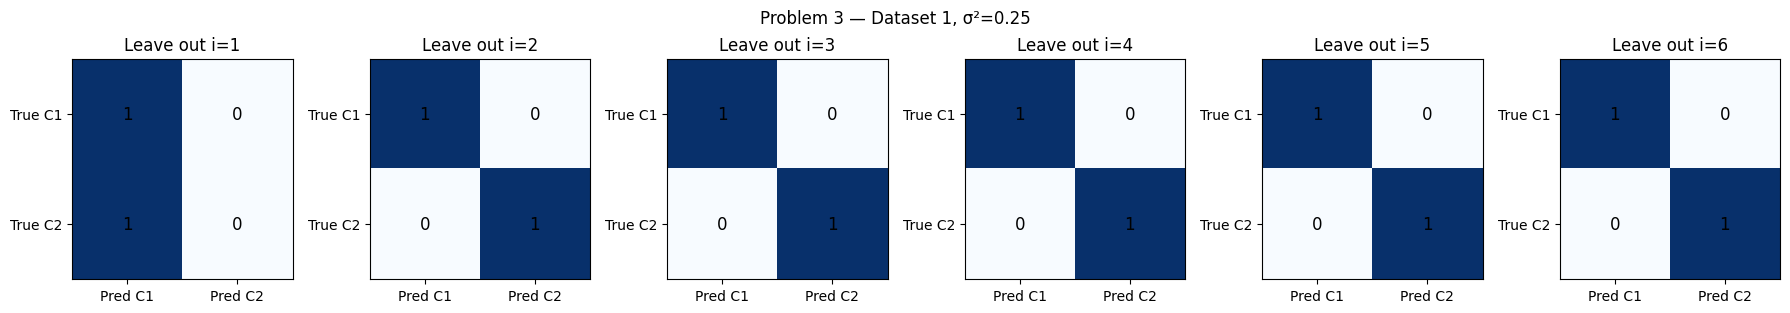

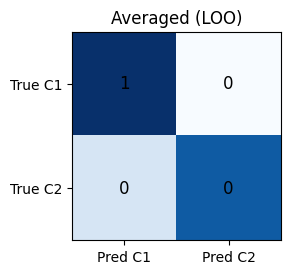

Leave-one-out avg error rate: 0.0833
Problem 2 N_D=5 avg error rate: 0.0294

Dataset 2, σ² = 0.49


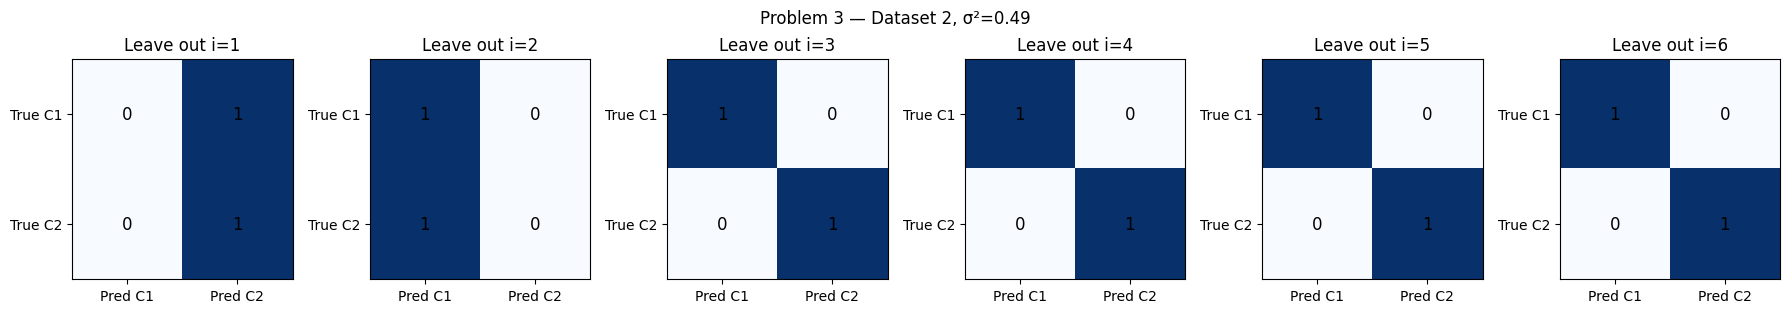

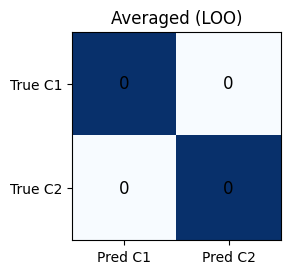

Leave-one-out avg error rate: 0.1667
Problem 2 N_D=5 avg error rate: 0.0294

Dataset 3, σ² = 1.0


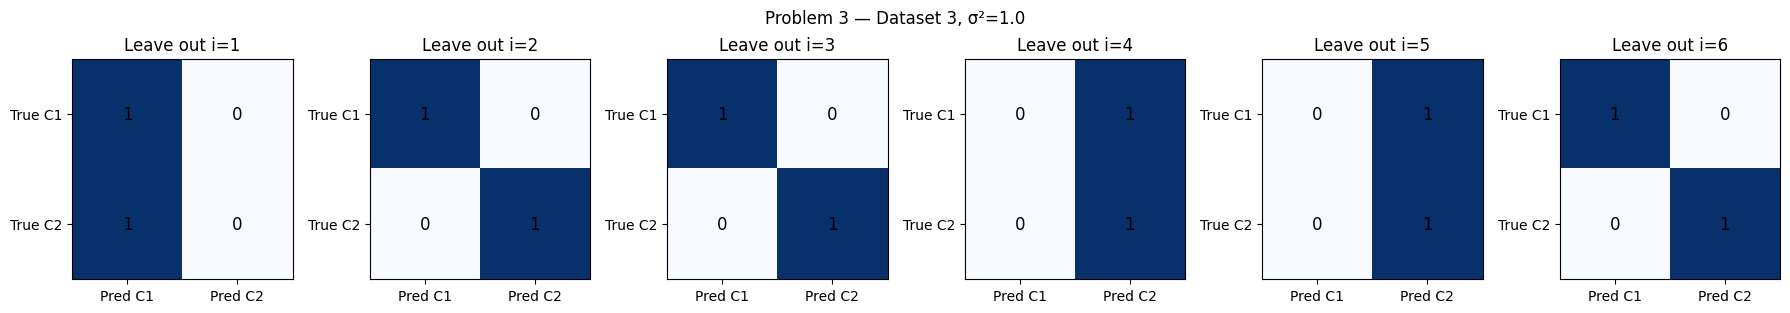

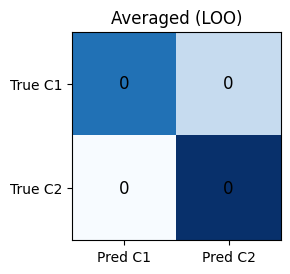

Leave-one-out avg error rate: 0.2500
Problem 2 N_D=5 avg error rate: 0.0294



In [172]:
ND_samples = [5, 20, 100]

for ds_idx in range(3):
    print(f"{'='*50}")
    print(f"Dataset {ds_idx+1}, σ² = {variances[ds_idx]}")
    print(f"{'='*50}")
    
    samples_c1 = datasets[ds_idx][0][:6]  # first 6 training samples, class 1
    samples_c2 = datasets[ds_idx][1][:6]  # first 6 training samples, class 2
    
    conf_matrices = []
    error_rates = []
    
    for i in range(6):
        # leave out sample i for testing, train on remaining 5
        train_c1 = np.delete(samples_c1, i)
        train_c2 = np.delete(samples_c2, i)
        test_c1  = samples_c1[i]
        test_c2  = samples_c2[i]
        
        # estimate boundary from 5 training samples
        mu1_est  = np.mean(train_c1)
        mu2_est  = np.mean(train_c2)
        boundary = (mu1_est + mu2_est) / 2
        
        # classify the 2 test samples
        pred_c1 = 1 if test_c1 < boundary else 2
        pred_c2 = 1 if test_c2 < boundary else 2
        
        conf = np.array([
            [1 if pred_c1 == 1 else 0,  1 if pred_c1 == 2 else 0],
            [1 if pred_c2 == 1 else 0,  1 if pred_c2 == 2 else 0]
        ])
        conf_matrices.append(conf)
        
        errors = (pred_c1 != 1) + (pred_c2 != 2)
        error_rates.append(errors / 2)
    
    # plot 6 individual confusion matrices
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    for i, conf in enumerate(conf_matrices):
        plot_confusion_matrix(conf, title=f'Leave out i={i+1}', ax=axes[i])
    plt.suptitle(f'Problem 3 — Dataset {ds_idx+1}, σ²={variances[ds_idx]}')
    plt.tight_layout()
    plt.show()
    
    # averaged confusion matrix and error rate
    avg_conf       = np.mean(conf_matrices, axis=0)
    avg_error_rate = np.mean(error_rates)
    
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    plot_confusion_matrix(avg_conf, title=f'Averaged (LOO)', ax=ax)
    plt.tight_layout()
    plt.show()
    
    print(f"Leave-one-out avg error rate: {avg_error_rate:.4f}")
    print(f"Problem 2 N_D=5 avg error rate: {(avg_conf_matrices_p2[0][0,1] + avg_conf_matrices_p2[0][1,0]) / (2*500):.4f}")
    print()


LOO is a good strategy when there is limited data. It does give unreliable error estimates though. 